TASK 3 : IPL Winning Team Prediction

The task is to build a Machine Learning model that predicts the winning
probability of an IPL match during the second innings using historical match and ball-by-ball data.
The model analyzes live match conditions such as runs left, balls remaining, wickets, and run rates to make accurate predictions.
The final solution includes data analysis, visualization, model training, and deployment with a user-friendly interface.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle


In [3]:
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')


In [ ]:
matches.head()


,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [4]:
deliveries.head()


,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


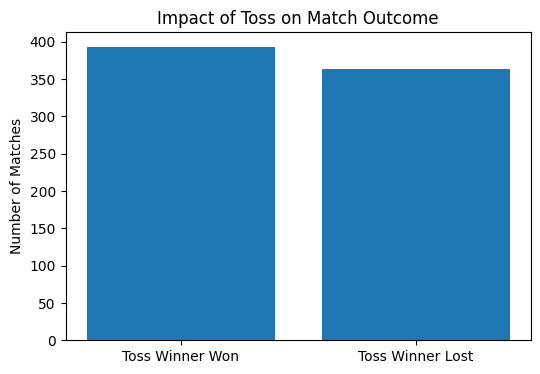

In [5]:
import matplotlib.pyplot as plt

toss_win = matches[matches['toss_winner'] == matches['winner']].shape[0]
toss_loss = matches.shape[0] - toss_win

plt.figure(figsize=(6,4))
plt.bar(['Toss Winner Won', 'Toss Winner Lost'], [toss_win, toss_loss])
plt.title('Impact of Toss on Match Outcome')
plt.ylabel('Number of Matches')
plt.show()


In [6]:
total_score_df = deliveries.groupby(['match_id','inning']).sum()['total_runs'].reset_index()
total_score_df = total_score_df[total_score_df['inning'] == 1]
total_score_df.head()


,match_id,inning,total_runs
0,1,1,207
2,2,1,184
4,3,1,183
6,4,1,163
8,5,1,157


In [7]:
match_df = matches.merge(
    total_score_df[['match_id','total_runs']],
    left_on='id',
    right_on='match_id'
)


In [8]:
teams = [
    'Sunrisers Hyderabad',
    'Mumbai Indians',
    'Royal Challengers Bangalore',
    'Kolkata Knight Riders',
    'Kings XI Punjab',
    'Chennai Super Kings',
    'Rajasthan Royals',
    'Delhi Capitals'
]

match_df['team1'] = match_df['team1'].str.replace('Delhi Daredevils','Delhi Capitals')
match_df['team2'] = match_df['team2'].str.replace('Delhi Daredevils','Delhi Capitals')

match_df['team1'] = match_df['team1'].str.replace('Deccan Chargers','Sunrisers Hyderabad')
match_df['team2'] = match_df['team2'].str.replace('Deccan Chargers','Sunrisers Hyderabad')

match_df = match_df[match_df['team1'].isin(teams)]
match_df = match_df[match_df['team2'].isin(teams)]


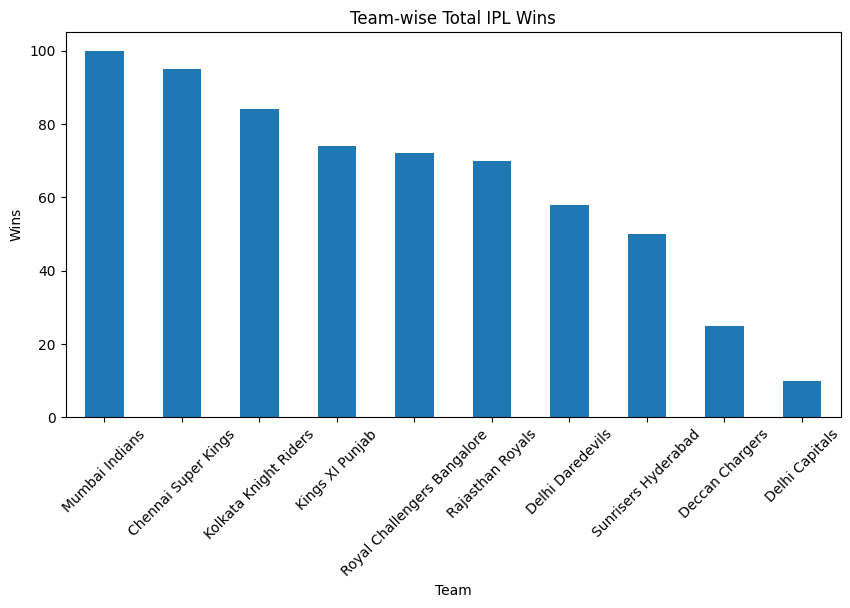

In [9]:
team_wins = match_df['winner'].value_counts()

plt.figure(figsize=(10,5))
team_wins.plot(kind='bar')
plt.title('Team-wise Total IPL Wins')
plt.ylabel('Wins')
plt.xlabel('Team')
plt.xticks(rotation=45)
plt.show()


In [10]:
match_df = match_df[match_df['dl_applied'] == 0]


In [11]:
match_df = match_df[['match_id','city','winner','total_runs']]


In [12]:
delivery_df = match_df.merge(deliveries,on='match_id')
delivery_df = delivery_df[delivery_df['inning'] == 2]


In [13]:
delivery_df['total_runs_y'] = pd.to_numeric(delivery_df['total_runs_y'], errors='coerce').astype(float)
delivery_df['current_score'] = delivery_df.groupby('match_id')['total_runs_y'].cumsum()

In [14]:
delivery_df['runs_left'] = delivery_df['total_runs_x'] - delivery_df['current_score']


In [15]:
delivery_df['balls_left'] = 126 - (delivery_df['over']*6 + delivery_df['ball'])


In [16]:
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].fillna("0")
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].apply(lambda x: 0 if x=="0" else 1).astype(int)
delivery_df['wickets'] = 10 - delivery_df.groupby('match_id')['player_dismissed'].cumsum()

In [17]:
delivery_df['crr'] = (delivery_df['current_score']*6)/(120 - delivery_df['balls_left'])
delivery_df['rrr'] = (delivery_df['runs_left']*6)/delivery_df['balls_left']


In [18]:
def match_result(row):
    return 1 if row['batting_team'] == row['winner'] else 0

delivery_df['result'] = delivery_df.apply(match_result,axis=1)


In [19]:
final_df = delivery_df[['batting_team','bowling_team','city',
                         'runs_left','balls_left','wickets',
                         'total_runs_x','crr','rrr','result']]

final_df = final_df.sample(final_df.shape[0])
final_df.dropna(inplace=True)
final_df = final_df[final_df['balls_left'] != 0]


In [20]:
X = final_df.iloc[:,:-1]
y = final_df.iloc[:,-1]

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=1
)


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

trf = ColumnTransformer([
    ('trf',OneHotEncoder(sparse_output=False,drop='first'),
     ['batting_team','bowling_team','city'])
], remainder='passthrough')

pipe = Pipeline(steps=[
    ('step1',trf),
    ('step2',LogisticRegression(solver='liblinear'))
])

In [22]:
pipe.fit(X_train,y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('step1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team', 'city'])])),
                ('step2', LogisticRegression(solver='liblinear'))])

In [23]:
from sklearn.metrics import accuracy_score
y_pred = pipe.predict(X_test)
accuracy_score(y_test,y_pred)


0.8062232812390497

In [24]:
sample_input = pd.DataFrame({
 'batting_team':['Chennai Super Kings'],
 'bowling_team':['Mumbai Indians'],
 'city':['Mumbai'],
 'runs_left':[45],
 'balls_left':[36],
 'wickets':[6],
 'total_runs_x':[180],
 'crr':[8.5],
 'rrr':[7.5]
})

pipe.predict_proba(sample_input)


array([[0.23103546, 0.76896454]])

In [25]:
pickle.dump(pipe,open('ipl_win_predictor.pkl','wb'))


In [26]:
proba = pipe.predict_proba(sample_input)[0]

print("🏏 Match Prediction Result")
print("---------------------------")
print(f"Chennai Super Kings Win Probability : {round(proba[1]*100, 2)}%")
print(f"Mumbai Indians Win Probability      : {round(proba[0]*100, 2)}%")


🏏 Match Prediction Result
---------------------------
Chennai Super Kings Win Probability : 76.9%
Mumbai Indians Win Probability      : 23.1%
